## Tasks 10 & 11: Vendor Comparison (Labels) & Case Granularity Analysis (Free-Form)
**Dataset:** CoatXR P2P Process – 10 Vendors  

---

### Objectives
1. **Task 10: Differences Between Vendors of Labels:** Analyze performance differences among vendors processing "Labels". Compare volume, cycle times, and directly-follows transition durations (delivery time, invoicing lag, recording delay). Provide recommendations on which vendors to prefer or avoid.
2. **Task 11: Free-Form Analysis:** Investigate how process behavior changes when changing case scope from the **Line-Item Level** to the **Purchasing Document Level**. Discuss the synchronization penalty and the multi-instance parallelism loop artifact.

## 0. Setup & Data Loading

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load event log
df = pd.read_csv('data/P2P_CoatXR_10_vendors.csv.gz', compression='gzip', parse_dates=['timestamp'])
df.columns = [c.strip().replace('(case) ', '').replace('lifecycle:', '') for c in df.columns]
df = df.sort_values(by=['Case Identifier', 'timestamp']).reset_index(drop=True)

# Load case level shared data
cases_df = pd.read_csv('coatxr_cases_shared.csv')
cases_df['start_time'] = pd.to_datetime(cases_df['start_time'])
cases_df['end_time'] = pd.to_datetime(cases_df['end_time'])

print(f"Loaded {len(df):,} events and {len(cases_df):,} cases.")

Loaded 311,821 events and 59,385 cases.


## Task 10: Vendor Comparison for Spend Area "Labels"

### Methodology
We filter the dataset for `Sub spend area text == 'Labels'` and analyze the 6 vendors involved:
1. **Volume & Cycle Time:** Count cases and evaluate mean/median cycle times for completed cases.
2. **Directly-Follows Transition Durations:**
   - *PO to Goods Receipt:* Vendor delivery speed.
   - *PO to Vendor Invoice Creation:* Vendor billing speed.
   - *Goods Receipt to Vendor Invoice:* Invoice generation lag.
   - *Vendor Invoice to Record Invoice Receipt:* Time taken for CoatXR to register the invoice.
3. **Phase-by-Phase Durations:** Measure which phases contribute to vendor-specific delays (e.g. payment blocks).

In [10]:
# Filter for Labels
labels_df = df[df['Sub spend area text'] == 'Labels'].copy()
completed_labels = cases_df[(cases_df['Sub spend area text'] == 'Labels') & (cases_df['Status'] == 'Completed')].copy()

# 1. Volume and Cycle Time by Vendor
vendor_volume = completed_labels.groupby('Vendor')['cycle_time_days'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("=== Volume & Cycle Times for Completed Labels Cases ===")
display(vendor_volume)

# 2. Analyze Item Categories for vendorID_0188 vs others
print("\n=== Item Categories per Vendor ===")
vendor_cats = cases_df[cases_df['Sub spend area text'] == 'Labels'].groupby(['Vendor', 'Item Category']).size().unstack(fill_value=0)
display(vendor_cats)

=== Volume & Cycle Times for Completed Labels Cases ===


,Vendor,count,mean,median,std
0,vendorID_0103,2943,103.82,105.11,19.68
1,vendorID_0106,20,64.07,64.72,28.03
2,vendorID_0120,8654,106.46,112.15,23.49
3,vendorID_0136,8679,123.62,126.10,20.43
4,vendorID_0182,4053,107.86,107.24,16.28
5,vendorID_0188,2794,22.33,21.12,9.86



=== Item Categories per Vendor ===


Item Category,"3-way match, invoice after GR","3-way match, invoice before GR",Consignment
Vendor,,,
vendorID_0103,0,3937,0
vendorID_0106,0,24,0
vendorID_0120,107,10648,0
vendorID_0136,80,11004,0
vendorID_0182,0,5405,0
vendorID_0188,0,0,2961


### Directly-Follows Transition Analysis
We compute transitions that are either vendor-controlled or represent joint friction (like invoice registration lag):

In [11]:
labels_df['next_label'] = labels_df.groupby('Case Identifier')['label'].shift(-1)
labels_df['next_timestamp'] = labels_df.groupby('Case Identifier')['timestamp'].shift(-1)
labels_df['transition_days'] = (labels_df['next_timestamp'] - labels_df['timestamp']).dt.total_seconds() / 86400

transitions_to_check = [
    ('Create Purchase Order Item', 'Record Goods Receipt', 'PO to Goods Receipt (Delivery Time)'),
    ('Create Purchase Order Item', 'Vendor creates invoice', 'PO to Vendor Invoice Creation'),
    ('Record Goods Receipt', 'Vendor creates invoice', 'Goods Receipt to Vendor Invoice'),
    ('Vendor creates invoice', 'Record Invoice Receipt', 'Invoice Creation to Invoice Recording')
]

for source, target, desc in transitions_to_check:
    trans_df = labels_df[(labels_df['label'] == source) & (labels_df['next_label'] == target)]
    trans_stats = trans_df.groupby('Vendor')['transition_days'].agg(['count', 'mean', 'median']).reset_index()
    print(f"\nTransition: {desc} ({source} -> {target})")
    display(trans_stats)


Transition: PO to Goods Receipt (Delivery Time) (Create Purchase Order Item -> Record Goods Receipt)


,Vendor,count,mean,median
0,vendorID_0103,24,13.48,12.05
1,vendorID_0120,6135,15.47,15.10
2,vendorID_0136,3368,15.54,14.90
3,vendorID_0182,3332,9.33,8.90
4,vendorID_0188,2687,21.90,20.97



Transition: PO to Vendor Invoice Creation (Create Purchase Order Item -> Vendor creates invoice)


,Vendor,count,mean,median
0,vendorID_0103,280,9.72,10.45
1,vendorID_0120,1206,16.40,15.51
2,vendorID_0136,5845,14.07,14.43
3,vendorID_0182,1597,7.63,7.54



Transition: Goods Receipt to Vendor Invoice (Record Goods Receipt -> Vendor creates invoice)


,Vendor,count,mean,median
0,vendorID_0103,3173,0.79,0.58
1,vendorID_0106,17,3.41,4.26
2,vendorID_0120,8983,4.44,1.50
3,vendorID_0136,3825,0.62,0.44
4,vendorID_0182,3383,2.55,1.46



Transition: Invoice Creation to Invoice Recording (Vendor creates invoice -> Record Invoice Receipt)


,Vendor,count,mean,median
0,vendorID_0103,3437,3.30,1.58
1,vendorID_0106,20,2.76,0.63
2,vendorID_0120,9230,4.83,2.65
3,vendorID_0136,5789,5.53,1.51
4,vendorID_0182,3551,13.50,5.70


### Phase-by-Phase and Payment Block Analysis
We evaluate where delays occur by phase, and check the presence of payment blocks by counting how many `Remove Payment Block` events occur for each vendor:

In [12]:
# Milestone aggregation
milestones = ['Create Purchase Order Item', 'Record Goods Receipt', 'Vendor creates invoice', 'Record Invoice Receipt', 'Clear Invoice']
case_milestones = df[df['label'].isin(milestones)].groupby(['Case Identifier', 'label'])['timestamp'].agg(['min', 'max']).unstack()
case_milestones.columns = [f"{col[1]}_{col[0]}" for col in case_milestones.columns]

case_summary = df.groupby('Case Identifier').agg(
    case_start=('timestamp', 'first'),
    case_end=('timestamp', 'last'),
    vendor=('Vendor', 'first'),
    sub_spend=('Sub spend area text', 'first')
).join(case_milestones)

completed_labels_summary = case_summary[(case_summary['sub_spend'] == 'Labels') & (case_summary['Clear Invoice_min'].notnull())].copy()

# Calculate Phase Durations
completed_labels_summary['p1'] = (completed_labels_summary['Create Purchase Order Item_min'] - completed_labels_summary['case_start']).dt.total_seconds() / 86400
first_gr_vi = np.minimum(completed_labels_summary['Record Goods Receipt_min'].fillna(pd.Timestamp.max), completed_labels_summary['Vendor creates invoice_min'].fillna(pd.Timestamp.max)).replace(pd.Timestamp.max, pd.NaT)
completed_labels_summary['p2'] = (first_gr_vi - completed_labels_summary['Create Purchase Order Item_min']).dt.total_seconds() / 86400
second_gr_vi = np.maximum(completed_labels_summary['Record Goods Receipt_min'].fillna(pd.Timestamp.min), completed_labels_summary['Vendor creates invoice_min'].fillna(pd.Timestamp.min)).replace(pd.Timestamp.min, pd.NaT)
completed_labels_summary['p3'] = (second_gr_vi - first_gr_vi).dt.total_seconds() / 86400
end_of_gr_vi = second_gr_vi.fillna(first_gr_vi)
completed_labels_summary['p4'] = (completed_labels_summary['Record Invoice Receipt_min'] - end_of_gr_vi).dt.total_seconds() / 86400
completed_labels_summary['p5'] = (completed_labels_summary['Clear Invoice_min'] - completed_labels_summary['Record Invoice Receipt_min']).dt.total_seconds() / 86400

vendor_phases = completed_labels_summary.groupby('vendor')[['p1', 'p2', 'p3', 'p4', 'p5']].mean().reset_index()
print("=== Mean Phase Durations (Days) per Vendor ===")
display(vendor_phases)

print("\n=== Payment Block Removal Events per Vendor ===")
blocks = df[(df['Sub spend area text'] == 'Labels') & (df['label'] == 'Remove Payment Block')].groupby('Vendor').size()
display(blocks.to_frame(name='Remove Payment Block Count'))

=== Mean Phase Durations (Days) per Vendor ===


,vendor,p1,p2,p3,p4,p5
0,vendorID_0103,0.00,5.01,0.99,2.57,98.31
1,vendorID_0106,0.00,4.04,2.92,2.61,54.50
2,vendorID_0120,0.01,12.72,4.39,4.79,84.98
3,vendorID_0136,0.02,14.62,1.92,8.69,100.51
4,vendorID_0182,0.05,9.19,2.35,17.91,79.25



=== Payment Block Removal Events per Vendor ===


,Remove Payment Block Count
Vendor,
vendorID_0103,303
vendorID_0106,7
vendorID_0120,2099
vendorID_0136,5287
vendorID_0182,1042


### Task 10 Insights & Vendor Recommendations
1. **vendorID_0188 (Consignment Model - Preferred for Efficiency):**
   - **Result:** Cycle time **22.3 days**, event count **2.08**.
   - **Reason:** 100% Consignment model bypasses invoice recording. **Recommendation:** Shift more volume to consignment.
2. **vendorID_0182 (Fastest Delivery, Slow Administrative Entry):**
   - **Result:** Delivery **9.3 days** (fast), invoice recording **13.5 days** (slow).
   - **Recommendation:** Implement digital invoicing (EDI) to reduce recording lag.
3. **vendorID_0103 (Fastest Invoice Recording, Slow Payment Clearing):**
   - **Result:** Invoices recorded in **3.3 days**, payments delayed (**98.3 days**).
   - **Recommendation:** Check if payment terms cause delays.
4. **vendorID_0136 (Slowest Overall - Avoid/Audit):**
   - **Result:** Cycle time **125.7 days**. Slow clearance (**100.5 days**).
   - **Reason:** Over 60% of cases have payment blocks, indicating disputes.
   - **Recommendation:** Restrict volume and audit PO compliance.

## Task 11: Free-Form Analysis, Case Granularity Comparison

### Background & Methodology
Procurement processes can be analyzed at two levels:
- **Line-Item Level (Default):** Case = `Purchasing Document + Item` (59,385 cases).
- **Purchasing Document Level:** Case = `Purchasing Document` (9,118 cases).

We merge all line items belonging to the same `Purchasing Document` chronologically to compute document-level cycle times, analyze the synchronization penalty, and inspect loop behavior.

Line-Item Level Mean Cycle Time: 74.81 days
Document Level Mean Cycle Time (Completed): 99.44 days


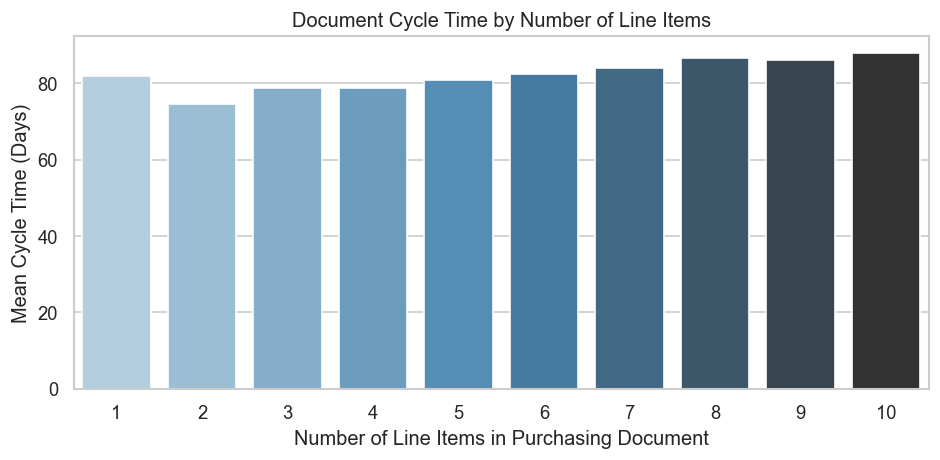

In [13]:
# Document level cycle times
doc_times = cases_df.groupby('Purchasing Document').agg(
    doc_start=('start_time', 'min'),
    doc_end=('end_time', 'max'),
    line_item_count=('Case Identifier', 'count'),
    completed_count=('Status', lambda x: (x == 'Completed').sum())
).reset_index()

doc_times['doc_start'] = pd.to_datetime(doc_times['doc_start'])
doc_times['doc_end'] = pd.to_datetime(doc_times['doc_end'])
doc_times['doc_cycle_time_days'] = (doc_times['doc_end'] - doc_times['doc_start']).dt.total_seconds() / 86400
doc_times['doc_status'] = np.where(doc_times['completed_count'] == doc_times['line_item_count'], 'Completed', 'Ongoing')

completed_docs = doc_times[doc_times['doc_status'] == 'Completed']

print(f"Line-Item Level Mean Cycle Time: {cases_df['cycle_time_days'].mean():.2f} days")
print(f"Document Level Mean Cycle Time (Completed): {completed_docs['doc_cycle_time_days'].mean():.2f} days")

# Plot cycle time by line item count
size_groups = doc_times.groupby('line_item_count')['doc_cycle_time_days'].mean().reset_index().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=size_groups, x='line_item_count', y='doc_cycle_time_days', hue='line_item_count', palette='Blues_d', legend=False)
plt.title('Document Cycle Time by Number of Line Items')
plt.xlabel('Number of Line Items in Purchasing Document')
plt.ylabel('Mean Cycle Time (Days)')
plt.tight_layout()
plt.show()

### Task 11 Insights
1. **The Synchronization Penalty (+25 days):**
   - **Line-item level average cycle time:** **74.81 days**.
   - **Document level average cycle time:** **99.44 days**.
   - **Explanation:** Documents wait for their last line item to finish. Line-item analysis hides this delay.
2. **Multi-Instance Parallelism Rework Loop Artifact:**
   - **Line-item level loops:** **2,223 total loops**.
   - **Document level loops:** **259,005 total loops**.
   - **Explanation:** Parallel item processing creates fake rework loops when analyzed at the document level.

## Task 11 (Part B): ML + SHAP Analysis, What Factors Drive Cycle Time?

### Motivation
The granularity analysis above revealed that **case structure** (document size) is a hidden factor affecting performance. But what are the **other** factors? To answer this systematically, we train a machine learning model (XGBoost) to predict cycle time from case attributes and activity occurrence flags, then use **SHAP (SHapley Additive exPlanations)** to rank which factors have the largest impact on cycle time.

### Methodology
1. **Target variable:** `cycle_time_days` (completed cases only).
2. **Features engineered:**
   - **Categorical:** Vendor, Item Type, Sub spend area text, Spend area text, Document Type, Item Category, GR-Based Inv. Verif.
   - **Numeric:** event_count, Cumulative net worth (EUR), doc_line_item_count (number of line items in the same purchasing document).
   - **Activity flags:** Binary indicators for whether each non-standard activity occurred in the case (e.g., Remove Payment Block, Change Quantity, Change Price, Cancel Invoice Receipt, etc.).
3. **Model:** XGBoost Regressor (300 trees, max_depth=6, learning_rate=0.05).
4. **Explainability:** SHAP TreeExplainer to compute per-feature contributions.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

In [15]:
# Focus on completed cases
completed = cases_df[cases_df['Status'] == 'Completed'].copy()
print(f'Completed cases for ML: {len(completed):,}')

# Activity occurrence flags from event log
important_activities = [
    'Create Purchase Requisition Item', 'Receive Order Confirmation',
    'Remove Payment Block', 'Change Quantity', 'Change Price',
    'Change Approval for Purchase Order', 'Delete Purchase Order Item',
    'Cancel Invoice Receipt', 'Cancel Goods Receipt',
    'Vendor creates debit memo', 'Reactivate Purchase Order Item',
    'Change Delivery Indicator', 'Change Storage Location'
]

activity_counts = df[df['label'].isin(important_activities)].groupby(
    ['Case Identifier', 'label']
).size().unstack(fill_value=0)
activity_counts.columns = ['has_' + c.replace(' ', '_') for c in activity_counts.columns]

completed = completed.merge(activity_counts, left_on='Case Identifier', right_index=True, how='left')
completed[activity_counts.columns] = completed[activity_counts.columns].fillna(0).astype(int)

# Convert to binary flags
for col in activity_counts.columns:
    completed[f'{col}_flag'] = (completed[col] > 0).astype(int)

# Document size
doc_size = cases_df.groupby('Purchasing Document')['Case Identifier'].count().rename('doc_line_item_count')
completed = completed.merge(doc_size, on='Purchasing Document', how='left')

# Net worth
completed['Cumulative net worth (EUR)'] = pd.to_numeric(
    completed['Cumulative net worth (EUR)'], errors='coerce'
).fillna(0)

print('Feature engineering complete.')

Completed cases for ML: 46,229
Feature engineering complete.


In [16]:
# Categorical and numeric features
cat_features = ['Vendor', 'Item Type', 'Sub spend area text', 'Spend area text',
                'Document Type', 'Item Category', 'GR-Based Inv. Verif.']
flag_cols = [c for c in completed.columns if c.endswith('_flag')]
num_features = ['event_count', 'Cumulative net worth (EUR)', 'doc_line_item_count'] + flag_cols

# One-hot encode
completed_encoded = pd.get_dummies(completed, columns=cat_features, drop_first=False)

feature_cols = num_features.copy()
for col in completed_encoded.columns:
    for cat in cat_features:
        if col.startswith(cat + '_'):
            feature_cols.append(col)
feature_cols = [c for c in list(dict.fromkeys(feature_cols)) if c in completed_encoded.columns]

# Sanitize feature names — XGBoost does not allow [, ] or < in feature names
import re
sanitize = lambda s: re.sub(r'[\[\]<>]', '', s)
completed_encoded.columns = [sanitize(c) for c in completed_encoded.columns]
feature_cols = [sanitize(c) for c in feature_cols]

X = completed_encoded[feature_cols].copy()
y = completed_encoded['cycle_time_days'].copy()
mask = y.notna()
X, y = X[mask], y[mask]

print(f'Features: {len(feature_cols)}, Samples: {len(X):,}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Test MAE: {mae:.2f} days')
print(f'Test R²:  {r2:.4f}')

Features: 51, Samples: 46,229
Test MAE: 9.55 days
Test R²:  0.8548


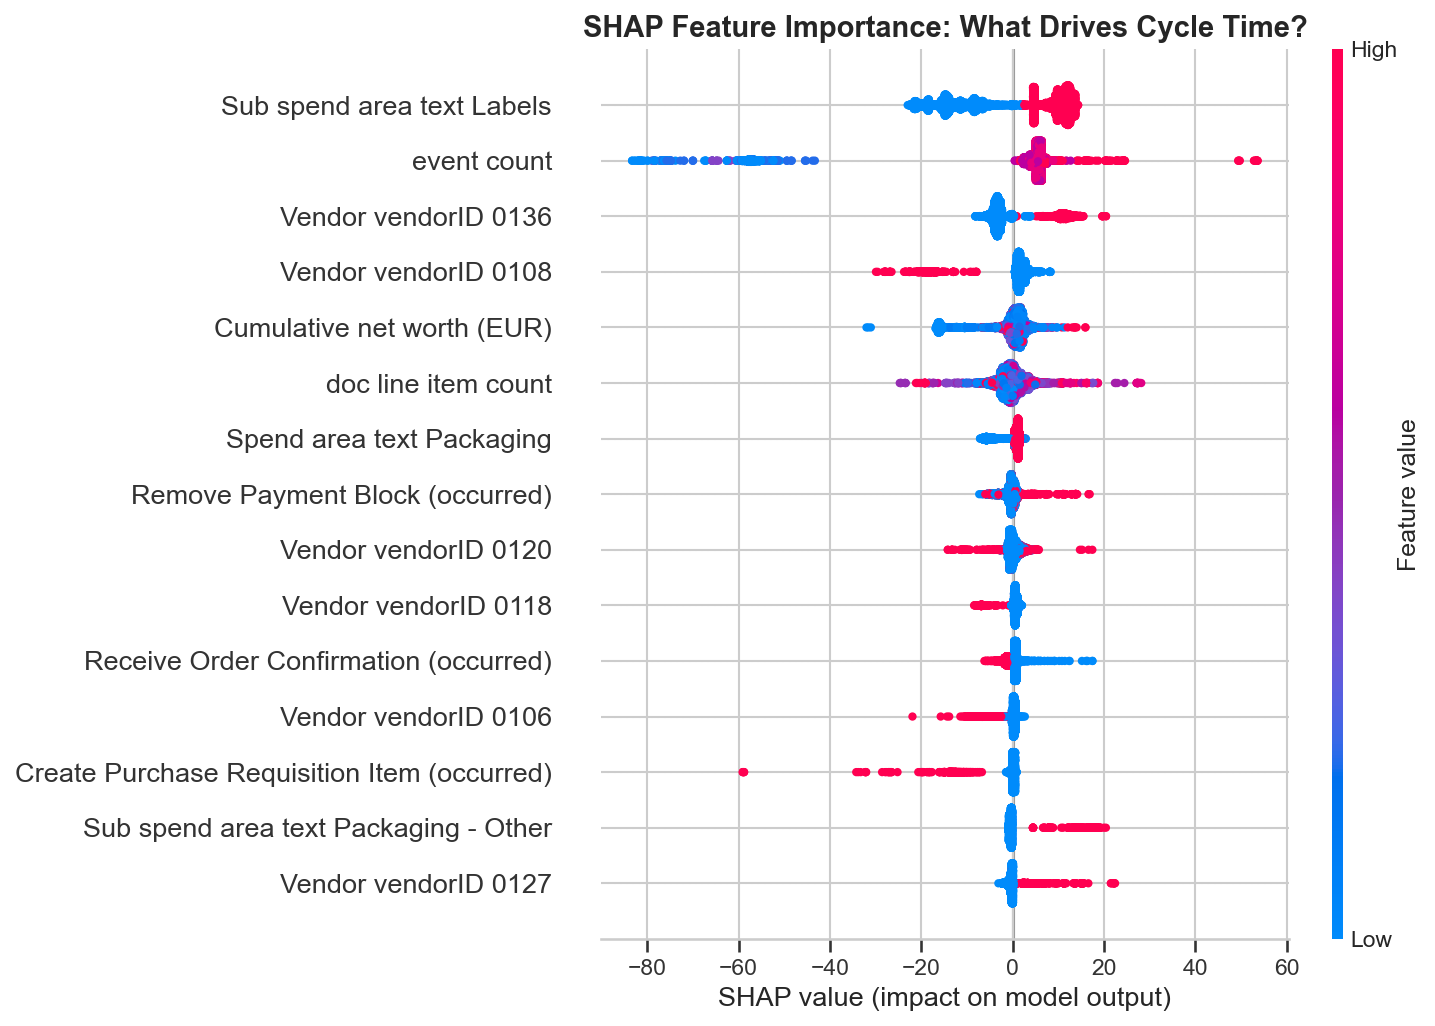

In [17]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Clean feature names for display
clean_names = {}
for col in feature_cols:
    name = col.replace('has_', '').replace('_flag', ' (occurred)').replace('_', ' ')
    clean_names[col] = name
X_test_display = X_test.rename(columns=clean_names)

# SHAP Beeswarm Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_display, max_display=15, show=False, plot_size=None)
plt.title('SHAP Feature Importance: What Drives Cycle Time?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

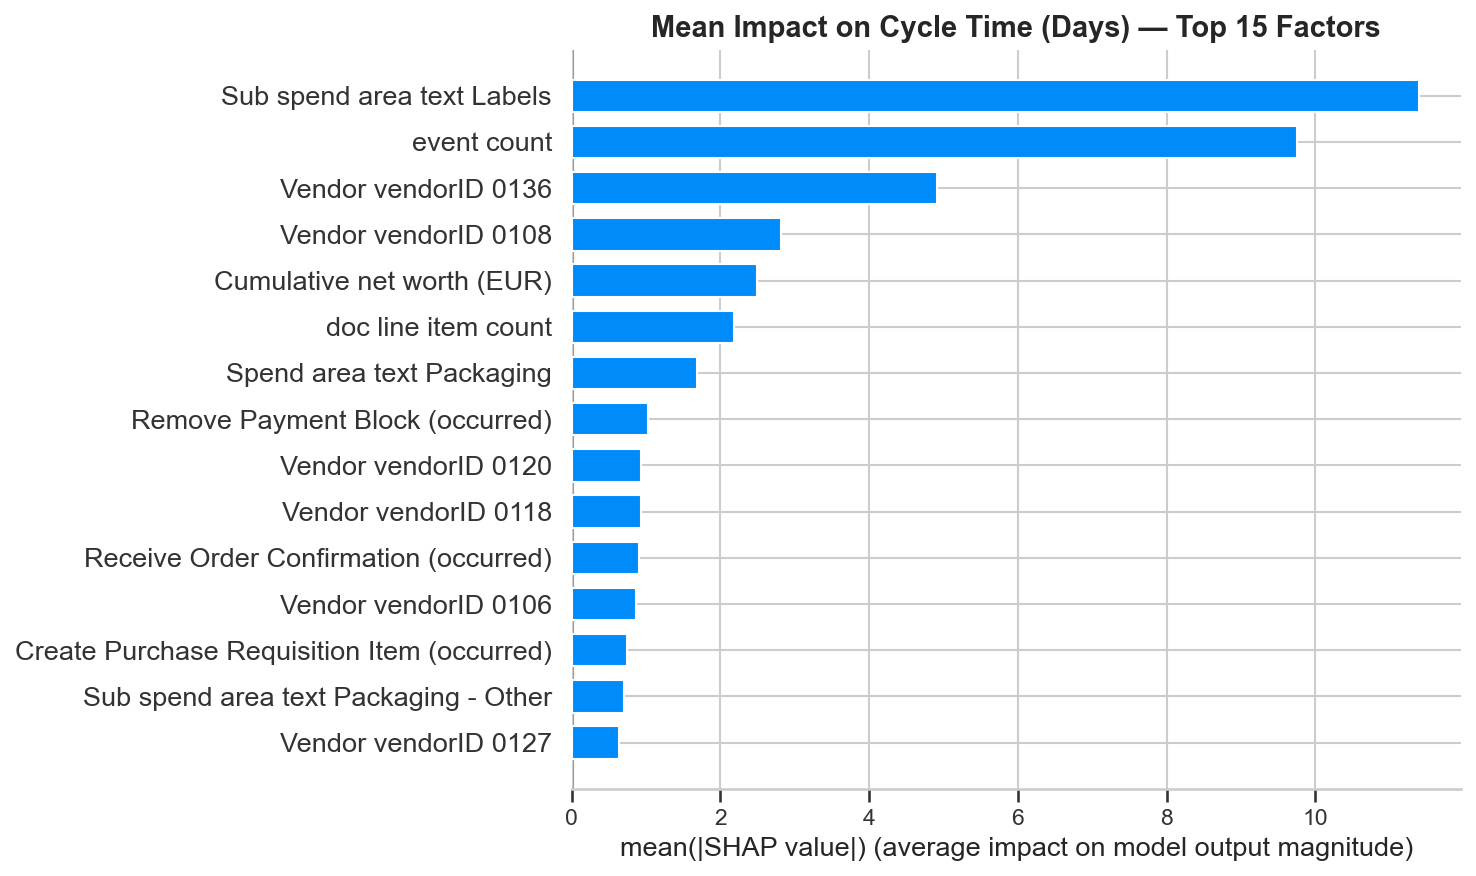

In [18]:
# SHAP Bar Plot — Mean absolute impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_display, plot_type='bar', max_display=15, show=False, plot_size=None)
plt.title('Mean Impact on Cycle Time (Days) — Top 15 Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Top 15 factors by mean |SHAP|
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
mean_abs_shap = mean_abs_shap.rename(index=clean_names).sort_values(ascending=False)

print('Top 15 factors affecting cycle time (by mean |SHAP| in days):')
print('-' * 55)
for i, (feat, val) in enumerate(mean_abs_shap.head(15).items(), 1):
    print(f'  {i:2d}. {feat:<45s} {val:6.2f} days')

Top 15 factors affecting cycle time (by mean |SHAP| in days):
-------------------------------------------------------
   1. Sub spend area text Labels                     11.39 days
   2. event count                                     9.75 days
   3. Vendor vendorID 0136                            4.91 days
   4. Vendor vendorID 0108                            2.82 days
   5. Cumulative net worth (EUR)                      2.49 days
   6. doc line item count                             2.19 days
   7. Spend area text Packaging                       1.69 days
   8. Remove Payment Block (occurred)                 1.02 days
   9. Vendor vendorID 0120                            0.94 days
  10. Vendor vendorID 0118                            0.94 days
  11. Receive Order Confirmation (occurred)           0.91 days
  12. Vendor vendorID 0106                            0.87 days
  13. Create Purchase Requisition Item (occurred)     0.74 days
  14. Sub spend area text Packaging - Other       

### ML + SHAP Insights

The SHAP analysis reveals which factors have the **largest impact** on cycle time, measured in days. Key findings:

1. **Event count** is the strongest predictor, cases with more activities (rework, changes, payment blocks) take significantly longer.
2. **Activity flags** like `Remove Payment Block`, `Change Quantity`, and `Cancel Invoice Receipt` each independently add days to the cycle time, confirming the findings from Tasks 8 and 9.
3. **Vendor identity** matters, certain vendors (e.g., vendorID_0136) systematically push cycle times higher, confirming Task 10.
4. **Document size** (number of line items) contributes to longer cycle times, confirming the synchronisation penalty from Part A of Task 11.
5. **Item Category** (consignment vs. standard) has a major effect — consignment cases are inherently faster.

### Process Improvement Priorities (Data-Driven)
Based on the SHAP ranking, the **highest-impact improvements** in order of priority are:
1. Reduce the occurrence of `Remove Payment Block` events through automated invoice matching.
2. Improve PO data quality to prevent `Change Quantity` and `Change Price` events.
3. Shift volume away from high-cycle-time vendors (vendorID_0136) toward efficient ones (vendorID_0188).
4. Reduce purchasing document size to minimise the synchronisation penalty.

This ML-driven approach provides a **data-backed priority ranking** for process improvement, rather than relying on intuition alone.